In [1]:
# Generated using Gemini with prompts. Only minimum edits are done to it.
# Bayes Rules! An Introduction to Applied Bayesian Modeling Book by Alicia A. Johnson, Miles Q. Ott, and Mine Dogucu was used to prompt

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
# Read the 'data' tab from the sephora.xlsx file
excel_file_path = '/content/Sephora Kids Linkedin (Responses).xlsx'
sheet_name = 'data'
df = pd.read_excel(excel_file_path, sheet_name=sheet_name)

# Calculate total children observed and total children using makeup from the initial survey
total_children_observed = df['Q1: How many kids aged 9–15 do you personally know?'].sum()
total_children_makeup = df['Q2: How many of those kids use makeup?'].sum()

# Group by 'Source' and calculate the sum of 'Q1' and 'Q2'
total_by_source = df.groupby('Source')[['Q1: How many kids aged 9–15 do you personally know?', 'Q2: How many of those kids use makeup?']].sum()

# Calculate the number of responses per source
response_counts = df.groupby('Source').size().reset_index(name='Number of Responses')

# Merge the total_by_source and response_counts DataFrames
total_by_source = pd.merge(total_by_source, response_counts, on='Source')


# Define the initial prior parameters
alpha_prior_initial = 4
beta_prior_initial = 5

# Calculate the posterior after initial survey
alpha_posterior_initial_survey = alpha_prior_initial + total_children_makeup
beta_posterior_initial_survey = beta_prior_initial + (total_children_observed - total_children_makeup)

# Calculate the posterior after Linkedin data first
linkedin_row = total_by_source[total_by_source['Source'] == 'Linkedin'].iloc[0]
kids_known_linkedin = linkedin_row['Q1: How many kids aged 9–15 do you personally know?']
kids_makeup_linkedin = linkedin_row['Q2: How many of those kids use makeup?']
alpha_posterior_linkedin = alpha_posterior_initial_survey + kids_makeup_linkedin
beta_posterior_linkedin = beta_posterior_initial_survey + (kids_known_linkedin - kids_makeup_linkedin)

# Calculate the posterior after Instagram data second
instagram_row = total_by_source[total_by_source['Source'] == 'Instagram'].iloc[0]
kids_known_instagram = instagram_row['Q1: How many kids aged 9–15 do you personally know?']
kids_makeup_instagram = instagram_row['Q2: How many of those kids use makeup?']
alpha_posterior_instagram = alpha_posterior_linkedin + kids_makeup_instagram
beta_posterior_instagram = beta_posterior_linkedin + (kids_known_instagram - kids_makeup_instagram)

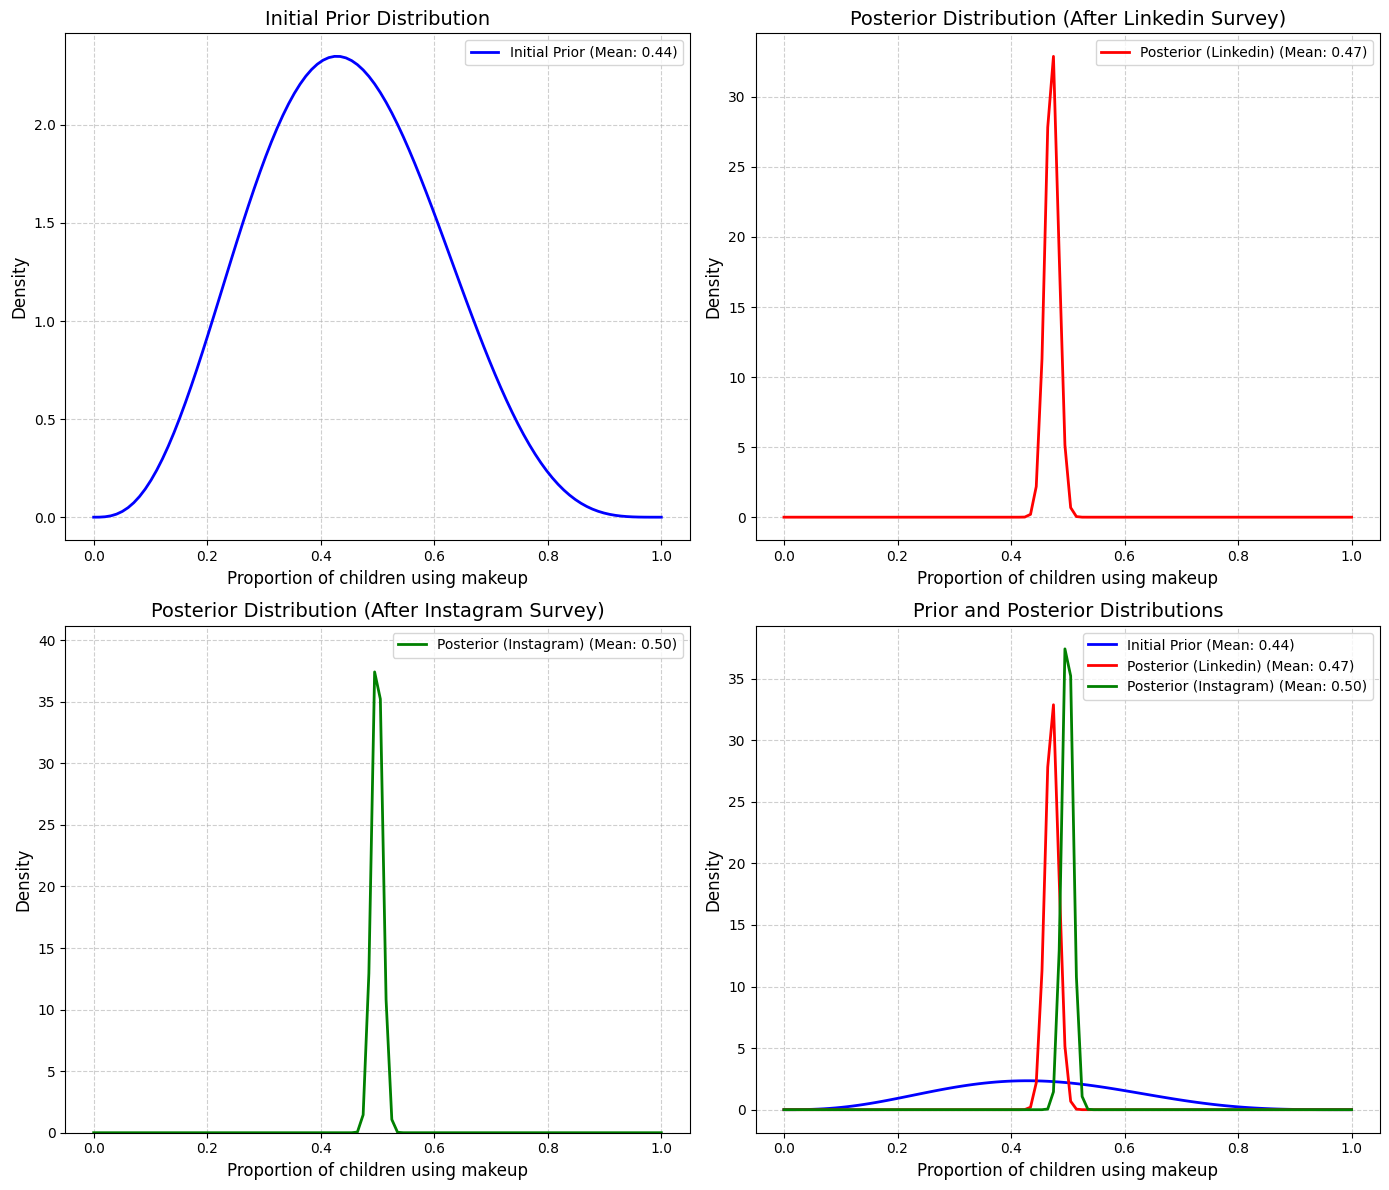

In [2]:
# Create a range of values for the x-axis
x = np.linspace(0, 1, 100)

# Calculate the PDF for each distribution
prior_pdf = beta.pdf(x, alpha_prior_initial, beta_prior_initial)
posterior_pdf_linkedin = beta.pdf(x, alpha_posterior_linkedin, beta_posterior_linkedin)
posterior_pdf_instagram = beta.pdf(x, alpha_posterior_instagram, beta_posterior_instagram)

# Calculate the mean for each distribution
mean_prior = alpha_prior_initial / (alpha_prior_initial + beta_prior_initial)
mean_posterior_linkedin = alpha_posterior_linkedin / (alpha_posterior_linkedin + beta_posterior_linkedin)
mean_posterior_instagram = alpha_posterior_instagram / (alpha_posterior_instagram + beta_posterior_instagram)


# Create a 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(14, 12)) # Increased figure size for better readability

# Plot the Prior in the first subplot (top-left)
axes[0, 0].plot(x, prior_pdf, label=f'Initial Prior (Mean: {mean_prior:.2f})', color='blue', linewidth=2) # Added linewidth
axes[0, 0].set_title('Initial Prior Distribution', fontsize=14) # Increased title font size
axes[0, 0].set_xlabel('Proportion of children using makeup', fontsize=12) # Increased label font size
axes[0, 0].set_ylabel('Density', fontsize=12) # Increased label font size
axes[0, 0].legend(fontsize=10) # Increased legend font size
axes[0, 0].grid(True, linestyle='--', alpha=0.6) # Added grid

# Plot the Posterior after Linkedin in the second subplot (top-right)
axes[0, 1].plot(x, posterior_pdf_linkedin, label=f'Posterior (Linkedin) (Mean: {mean_posterior_linkedin:.2f})', color='red', linewidth=2) # Added linewidth
axes[0, 1].set_title('Posterior Distribution (After Linkedin Survey)', fontsize=14) # Increased title font size
axes[0, 1].set_xlabel('Proportion of children using makeup', fontsize=12) # Increased label font size
axes[0, 1].set_ylabel('Density', fontsize=12) # Increased label font size
axes[0, 1].legend(fontsize=10) # Increased legend font size
axes[0, 1].grid(True, linestyle='--', alpha=0.6) # Added grid


# Plot the Posterior after Instagram in the third subplot (bottom-left)
axes[1, 0].plot(x, posterior_pdf_instagram, label=f'Posterior (Instagram) (Mean: {mean_posterior_instagram:.2f})', color='green', linewidth=2) # Added linewidth
axes[1, 0].set_title('Posterior Distribution (After Instagram Survey)', fontsize=14) # Increased title font size
axes[1, 0].set_xlabel('Proportion of children using makeup', fontsize=12) # Increased label font size
axes[1, 0].set_ylabel('Density', fontsize=12) # Increased label font size
axes[1, 0].legend(fontsize=10) # Increased legend font size
axes[1, 0].grid(True, linestyle='--', alpha=0.6) # Added grid
# Adjust y-axis limits to make differences more prominent
axes[1, 0].set_ylim(0, max(posterior_pdf_instagram.max(), posterior_pdf_linkedin.max()) * 1.1)


# Plot all three on the fourth subplot (bottom-right)
axes[1, 1].plot(x, prior_pdf, label=f'Initial Prior (Mean: {mean_prior:.2f})', color='blue', linewidth=2) # Added linewidth
axes[1, 1].plot(x, posterior_pdf_linkedin, label=f'Posterior (Linkedin) (Mean: {mean_posterior_linkedin:.2f})', color='red', linewidth=2) # Added linewidth
axes[1, 1].plot(x, posterior_pdf_instagram, label=f'Posterior (Instagram) (Mean: {mean_posterior_instagram:.2f})', color='green', linewidth=2) # Added linewidth
axes[1, 1].set_title('Prior and Posterior Distributions', fontsize=14) # Increased title font size
axes[1, 1].set_xlabel('Proportion of children using makeup', fontsize=12) # Increased label font size
axes[1, 1].set_ylabel('Density', fontsize=12) # Increased label font size
axes[1, 1].legend(fontsize=10) # Increased legend font size
axes[1, 1].grid(True, linestyle='--', alpha=0.6) # Added grid


# Adjust layout to prevent overlapping titles and labels
plt.tight_layout()

# Save the entire figure as a high-resolution image
fig.savefig('all_distributions_2x2.png', dpi=300, bbox_inches='tight')


# Display the plot
plt.show()

In [ ]:
# Calculate the variance for each stage
variance_prior = beta.var(alpha_prior_initial, beta_prior_initial)
variance_posterior_linkedin = beta.var(alpha_posterior_linkedin, beta_posterior_linkedin)
variance_posterior_instagram = beta.var(alpha_posterior_instagram, beta_posterior_instagram)

# Calculate the 95% credible interval for each stage
# The beta.interval function returns the lower and upper bounds of the interval
ci_prior = beta.interval(0.95, alpha_prior_initial, beta_prior_initial)
ci_posterior_linkedin = beta.interval(0.95, alpha_posterior_linkedin, beta_posterior_linkedin)
ci_posterior_instagram = beta.interval(0.95, alpha_posterior_instagram, beta_posterior_instagram)

# Combine all the data into a single dictionary
combined_data = {
    'Stage': ['Initial Prior', 'After Linkedin Data', 'After Instagram Data'],
    'Mean Proportion': [mean_prior, mean_posterior_linkedin, mean_posterior_instagram],
    'Alpha': [alpha_prior_initial, alpha_posterior_linkedin, alpha_posterior_instagram],
    'Beta': [beta_prior_initial, beta_posterior_linkedin, beta_posterior_instagram],
    'Variance': [variance_prior, variance_posterior_linkedin, variance_posterior_instagram]
}

# Create a pandas DataFrame
combined_df = pd.DataFrame(combined_data)

# Display the DataFrame
display(combined_df)

,Stage,Mean Proportion,Alpha,Beta,Variance
0,Initial Prior,0.444444,4,5,0.024691
1,After Linkedin Data,0.472036,844,944,0.000139
2,After Instagram Data,0.499455,1374,1377,0.000091


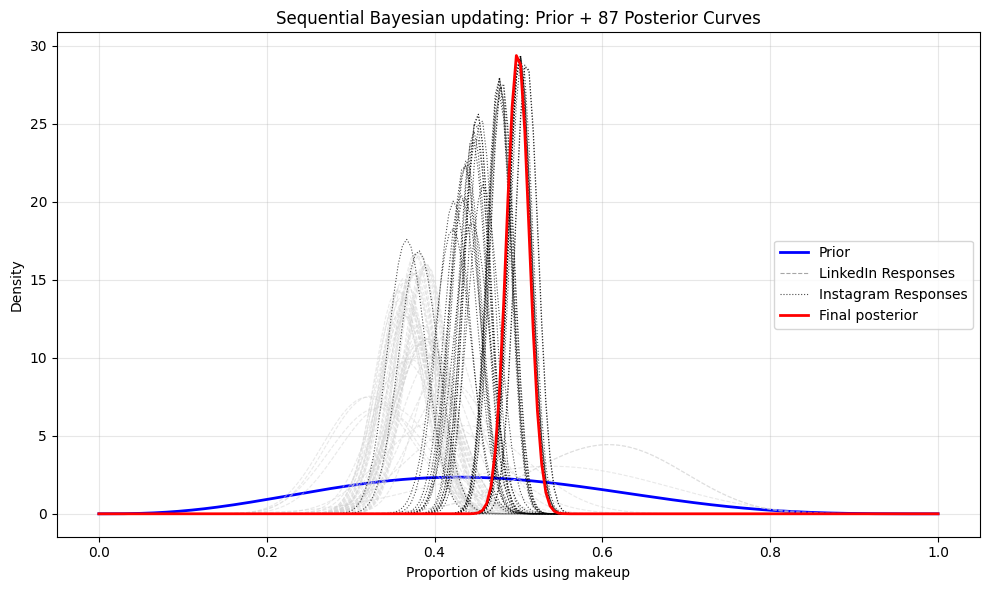

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# load your data
excel_file_path = '/content/Sephora Kids Linkedin (Responses).xlsx'
sheet_name = 'data'
df = pd.read_excel(excel_file_path, sheet_name=sheet_name)

kids_known  = df['Q1: How many kids aged 9–15 do you personally know?'].values
kids_makeup = df['Q2: How many of those kids use makeup?'].values
sources     = df['Source'].values  # Should contain "LinkedIn" or "Instagram"
n_obs = len(kids_known)

# initial prior parameters
alpha0 = 4
beta0  = 5

# x axis for plotting Beta pdfs
x = np.linspace(0, 1, 200)

# initialize parameters for updating
alpha = alpha0
beta_ = beta0

plt.figure(figsize=(10,6))

# Plot the prior (blue)
y_prior = beta.pdf(x, alpha0, beta0)
plt.plot(x, y_prior, color='blue', lw=2, label='Prior')

# Add “dummy” lines so LinkedIn / Instagram show up in legend
plt.plot([], [], color='grey', linestyle='--', lw=0.8, alpha=0.7, label='LinkedIn Responses')
plt.plot([], [], color='black', linestyle=':', lw=0.8, alpha=0.7, label='Instagram Responses')

# Sequential updates & plotting
for i in range(n_obs):
    alpha += kids_makeup[i]
    beta_  += (kids_known[i] - kids_makeup[i])
    y = beta.pdf(x, alpha, beta_)

    if i < n_obs - 1:
        if sources[i] == 'LinkedIn':
            plt.plot(x, y, color='grey', linestyle='-', lw=0.8, alpha=0.7)
        elif sources[i] == 'Instagram':
            plt.plot(x, y, color='black', linestyle=':', lw=0.8, alpha=0.7)
        else:
            plt.plot(x, y, color='lightgrey', linestyle='--', lw=0.8, alpha=0.5)
    else:
        # Final posterior in red
        plt.plot(x, y, color='red', lw=2, label='Final posterior')

plt.xlabel('Proportion of kids using makeup')
plt.ylabel('Density')
plt.title('Sequential Bayesian updating: Prior + 87 Posterior Curves')
plt.legend(loc='right')  # put legend on the side
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('posterior_updates.png', dpi=600, bbox_inches='tight')
plt.show()
